In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei','DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

X_train,X_test,y_train,y_test = train_test_split(
    cancer.data,cancer.target,random_state=0)
print("="*50)
print("乳腺癌数据集")
print("="*50)
print(f"训练集大小:{X_train.shape[0]}个样本")
print(f"测试集大小:{X_test.shape[0]}个样本")
print(f"特征数量:{X_train.shape[1]}个")


乳腺癌数据集
训练集大小:426个样本
测试集大小:143个样本
特征数量:30个


In [2]:
forest = RandomForestClassifier(n_estimators=100,random_state=0,n_jobs=-1)

forest.fit(X_train,y_train)

print("="*50)
print("随机森林模型")
print("="*50)
print(f"训练集精度:{forest.score(X_train,y_train):.3f}")
print(f"测试集精度:{forest.score(X_test,y_test):.3f}")

随机森林模型
训练集精度:1.000
测试集精度:0.972


In [3]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train,y_train)

print("="*50)
print("单棵决策树vs随机森林对比")
print("="*50)
print(f"单棵决策树 - 训练集:{tree.score(X_train,y_train):.3f}，测试集:{tree.score(X_test,y_test):.3f}")
print(f"随机森林   - 训练集:{forest.score(X_train,y_train):.3f},测试集:{forest.score(X_test,y_test):.3f}")

单棵决策树vs随机森林对比
单棵决策树 - 训练集:1.000，测试集:0.881
随机森林   - 训练集:1.000,测试集:0.972


随机森林特征重要性排名
前10个最重要的特征：
1.worst perimeter:0.1603
2.worst concave points:0.1171
3.worst radius:0.1166
4.mean concave points:0.1031
5.worst area:0.0635
6.mean concavity:0.0554
7.mean perimeter:0.0537
8.mean area:0.0486
9.worst concavity:0.0392
10.area error:0.0342


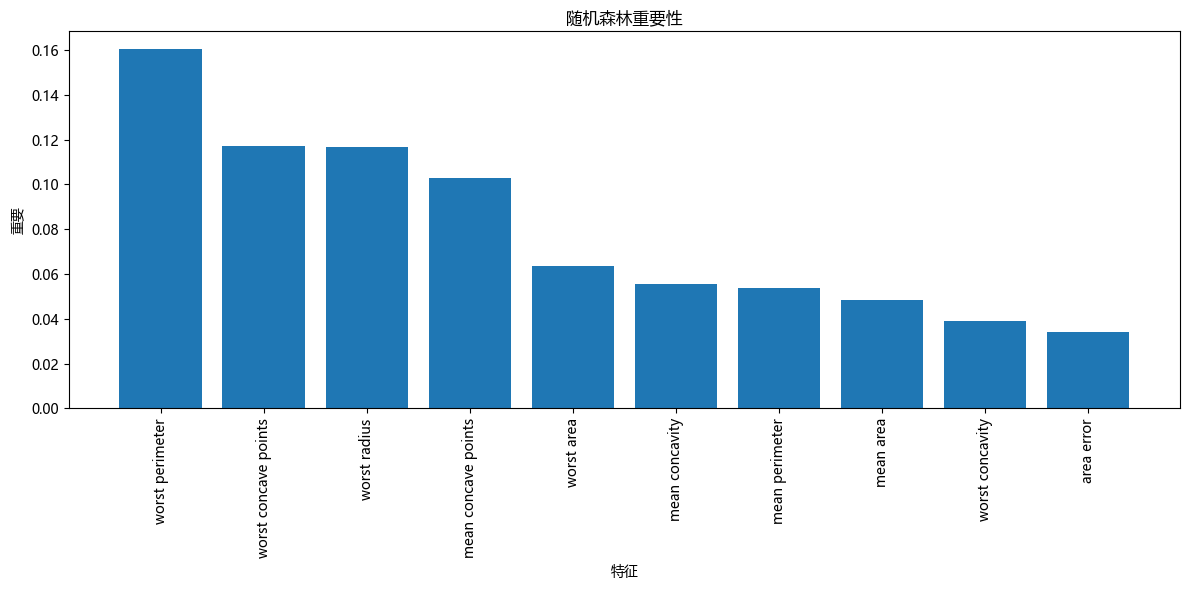

In [4]:
importances = forest.feature_importances_

indices = np.argsort(importances)[::-1]

print("="*50)
print("随机森林特征重要性排名")
print("="*50)
print("前10个最重要的特征：")
for i in range(10):
    print(f"{i+1}.{cancer.feature_names[indices[i]]}:{importances[indices[i]]:.4f}")

plt.figure(figsize=(12,6))
plt.bar(range(10),importances[indices[:10]])
plt.xticks(range(10),[cancer.feature_names[i] for i in indices[:10]],rotation=90)
plt.xlabel('特征')
plt.ylabel('重要')
plt.title('随机森林重要性')
plt.tight_layout()
plt.show()

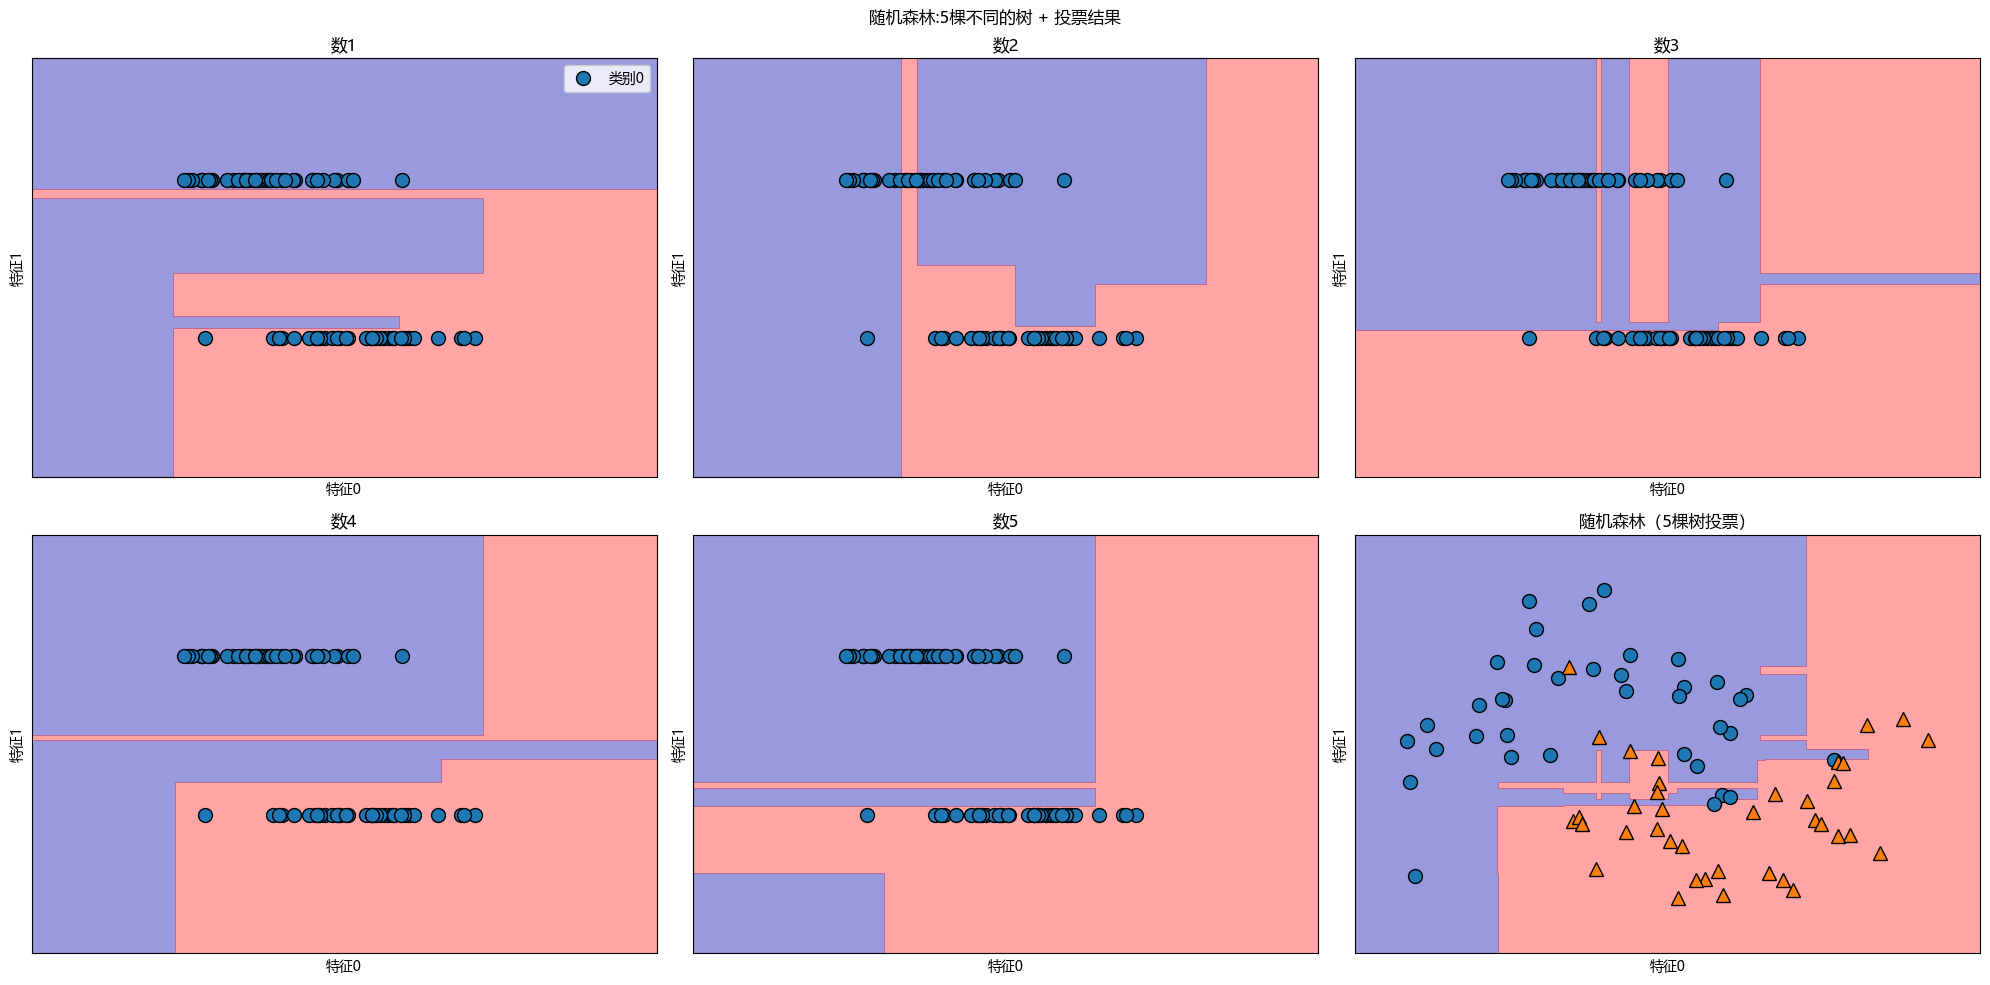

In [9]:
from sklearn.datasets import make_moons

X_moons,y_moons = make_moons(n_samples=100,noise=0.25,random_state=3)

X_train_m,X_test_m,y_train_m,y_test_m = train_test_split(
    X_moons,y_moons,stratify=y_moons,random_state=42)

forest_small = RandomForestClassifier(n_estimators=5,random_state=2)
forest_small.fit(X_train_m,y_train_m)

fig,axes = plt.subplots(2,3,figsize=(20,10))

for i,(ax,tree) in enumerate(zip(axes.ravel(),forest_small.estimators_)):
    mglearn.plots.plot_2d_separator(tree,X_train_m,fill=True,alpha=0.4,ax=ax)
    mglearn.discrete_scatter(X_train_m[:,1],y_train_m,ax=ax)
    ax.set_title(f"数{i+1}")
    ax.set_xlabel("特征0")
    ax.set_ylabel("特征1")

ax = axes[1,2]
mglearn.plots.plot_2d_separator(forest_small,X_train_m,fill=True,alpha=0.4,ax=ax)
mglearn.discrete_scatter(X_train_m[:,0],X_train_m[:,1],y_train_m,ax=ax)
ax.set_title("随机森林（5棵树投票）")
ax.set_xlabel("特征0")
ax.set_ylabel("特征1")

axes[0,0].legend(["类别0","类别1"],loc="best")
plt.suptitle("随机森林:5棵不同的树 + 投票结果")
plt.tight_layout()
plt.show()

n_estimators=  1 - 训练:0.960,测试:0.881
n_estimators=  5 - 训练:0.995,测试:0.944
n_estimators= 10 - 训练:1.000,测试:0.951
n_estimators= 50 - 训练:1.000,测试:0.965
n_estimators=100 - 训练:1.000,测试:0.972


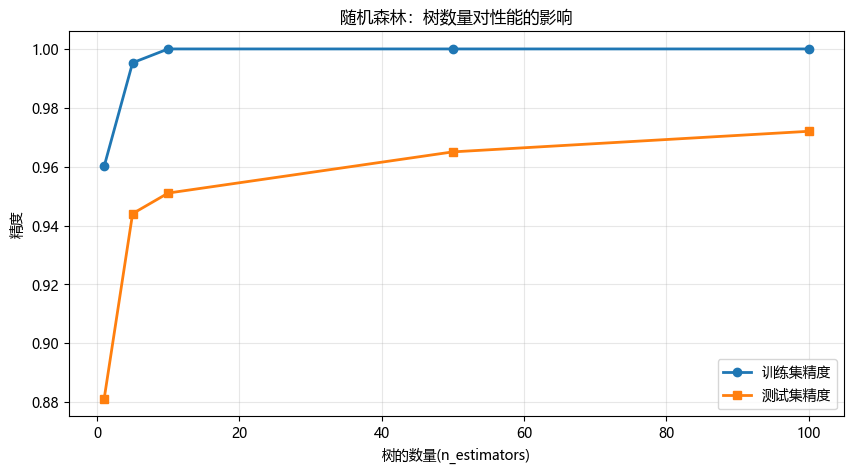

In [12]:
n_estimators_list = [1,5,10,50,100]
train_scores = []
test_scores = []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n,random_state=0,n_jobs=-1)
    rf.fit(X_train,y_train)
    train_scores.append(rf.score(X_train,y_train))
    test_scores.append(rf.score(X_test,y_test))
    print(f"n_estimators={n:3d} - 训练:{train_scores[-1]:.3f},测试:{test_scores[-1]:.3f}")

plt.figure(figsize=(10,5))
plt.plot(n_estimators_list,train_scores,'o-',label='训练集精度',linewidth=2)
plt.plot(n_estimators_list,test_scores,'s-',label='测试集精度',linewidth=2)
plt.xlabel('树的数量(n_estimators)')
plt.ylabel('精度')
plt.title('随机森林：树数量对性能的影响')
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()